# <h1><b>Título: Notebook de introducción a Pandas para lectura de datos</b></h1>

<b>Autor: </b><i>Manuel Pegalajar Cuéllar</i>

<b>Asignatura:</b> Aprendizaje Automático


<center><img src="https://upload.wikimedia.org/wikipedia/commons/thumb/e/ed/Pandas_logo.svg/300px-Pandas_logo.svg.png"/></center>

# Lectura de datos

Pandas normalmente se importa con alias:

In [ ]:
import pandas as pd

Los métodos para cargar un conjunto de datos en un **Dataframe** (tabla) comienzan por *read*:

- read_csv : Lectura de un fichero CSV
- read_html : Lectura de una web HTML
- read_json : lectura de un fichero JSON
- read_pickle : Lectura de un fichero pickle
- read_sql : Lectura de Base de Datos usando consulta SQL
- ...

Nos centraremos en read_csv mediante un ejemplo:

In [ ]:
# EJEMPLO: Creación de fichero .CSV usando NumPy
import numpy as np

# Datos de la función XOR
xor= [['X', 'Y', 'SALIDA'], # Cabecera: entradas X,Y. Salidas: SALIDA
      ['Falso', 'Negativo', 'NO'], # (entrada falso, falso. salida: no)
      ['Falso', 'Positivo', 'SI'], # (entrada falso, cierto. salida: si)
      ['Cierto', 'Negativo', 'SI'], # (entrada cierto, falso. salida: si)
      ['Cierto', 'Positivo', 'NO'] # (entrada cierto, cierto. salida: no)
     ]

xor_data= np.array(xor, dtype=str)
print('dataset del XOR (tipo {}):\n{}'.format(xor_data.dtype, xor_data))


# Un ejemplo práctico del uso de unique:
print('---\nAnálisis del dominio:\n')
for i in range(len(xor_data[0])):
  print('El dominio de {} es: {}'.format(xor_data[0, i], np.unique(xor_data[1:, i])))
print('---\n')

# guardar a fichero de texto con delimitador coma
np.savetxt('xor.csv', xor_data, delimiter=',', fmt="%s")


dataset del XOR (tipo <U8):
[['X' 'Y' 'SALIDA']
 ['Falso' 'Negativo' 'NO']
 ['Falso' 'Positivo' 'SI']
 ['Cierto' 'Negativo' 'SI']
 ['Cierto' 'Positivo' 'NO']]
---
Análisis del dominio:

El dominio de X es: ['Cierto' 'Falso']
El dominio de Y es: ['Negativo' 'Positivo']
El dominio de SALIDA es: ['NO' 'SI']
---



In [ ]:
# LECTURA DEL FICHERO ANTERIOR USANDO PANDAS
import pandas as pd

# Usamos read_csv para cargar un CSV con celdas delimitadas por comas
# el resultado es un Dataframe
df= pd.read_csv('xor.csv', delimiter=',')

# Mostrar las primeras líneas del fichero
df.head(3)

,X,Y,SALIDA
0,Falso,Negativo,NO
1,Falso,Positivo,SI
2,Cierto,Negativo,SI


## Lectura de datos desde web

La interfaz de Pandas permite, entre otras cosas, cargar ficheros que se encuentren online. Únicamente es necesario proporcionar la URL donde se encuentra el fichero.

In [ ]:
import pandas as pd

# La URL donde se encuentran los datos
# Dataset Wine: Clasificación de vinos utilizando datos de análisis químico
URL_datos= "https://gist.githubusercontent.com/tijptjik/9408623/raw/b237fa5848349a14a14e5d4107dc7897c21951f5/wine.csv"

df= pd.read_csv(URL_datos)
df.head(5)

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


## El tipo **Series**

Un objeto **Series** se corresponde con un conjunto de datos 1-D (columna de un Dataframe). Podemos crear objetos series desde Python, como por ejemplo:

In [ ]:
import numpy as np
import pandas as pd

r= np.random.rand(10)
s= pd.Series(data= r, name= 'Aleatorios')
s



,Aleatorios
0,0.513679
1,0.081153
2,0.096156
3,0.413914
4,0.438236
5,0.904210
6,0.816267
7,0.306350
8,0.440477
9,0.148964


## Creación de **DataFrames**

Hay muchas formas de crear un Dataframe. Una de las más sencillas es proporcionar cada columna como un diccionario, donde la clave es el nombre de la columna y su valor una lista con los datos de las celdas:

In [ ]:
import pandas as pd

ticket_compra= {'item' : ['Pechuga de pollo', 'Manzanas', 'Jamón York'],
                'Cantidad' : [0.5, 1, 0.25],
                'Precio/kg': [8, 2.35, 10]}

df= pd.DataFrame(ticket_compra)
df

,item,Cantidad,Precio/kg
0,Pechuga de pollo,0.50,8.00
1,Manzanas,1.00,2.35
2,Jamón York,0.25,10.00


Se pueden insertar nuevas columnas en línea en el dataframe, simplemente tratándolo como un diccionario:

In [ ]:
df['IVA']= [0.21, 0.21, 0.18]
df

,item,Cantidad,Precio/kg,IVA
0,Pechuga de pollo,0.50,8.00,0.21
1,Manzanas,1.00,2.35,0.21
2,Jamón York,0.25,10.00,0.18


# Inspección inicial de los datos

La inspección inicial de los datos es una labor muy importante, cuyo objeto es **comprender el problema que se desea resolver**. Algunas funcionalidades básicas de **Pandas** para conseguirlo:

### Mostrar los n primeros registros del conjunto de datos

In [ ]:
df.head(2)

,item,Cantidad,Precio/kg
0,Pechuga de pollo,0.5,8.00
1,Manzanas,1.0,2.35


### Mostrar los n últimos datos del conjunto

In [ ]:
df.tail(2)

,item,Cantidad,Precio/kg
1,Manzanas,1.00,2.35
2,Jamón York,0.25,10.00


### Mostrar una selección aleatoria de n registros

In [ ]:
df.sample(2)

,item,Cantidad,Precio/kg
2,Jamón York,0.25,10.00
1,Manzanas,1.00,2.35


### Acceso al tamaño del conjunto de datos

In [ ]:
print('Tamaño del conjunto: {}'.format(df.shape))
print('Son {} filas y {} columnas.'.format(df.shape[0], df.shape[1]))

Tamaño del conjunto: (3, 3)
Son 3 filas y 3 columnas.


### Información sobre los datos (atributos de un registro, sus tipos de datos, valores perdidos...)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   item       3 non-null      object 
 1   Cantidad   3 non-null      float64
 2   Precio/kg  3 non-null      float64
dtypes: float64(2), object(1)
memory usage: 200.0+ bytes


### Descripción estadística del conjunto de datos (rango de atributos, media, desviación estándar...)

In [ ]:
df.describe()

,Cantidad,Precio/kg
count,3.000000,3.000000
mean,0.583333,6.783333
std,0.381881,3.967472
min,0.250000,2.350000
25%,0.375000,5.175000
50%,0.500000,8.000000
75%,0.750000,9.000000
max,1.000000,10.000000


## Generación de gráficas

A cada serie de datos de columna se puede acceder como si fuese un atributo del dataframe:

In [ ]:
# Mostrar los ítems de la compra
print('Items de la compra: {}'.format( df.item ))

Items de la compra: 0    Pechuga de pollo
1            Manzanas
2          Jamón York
3                 NaN
4                 NaN
5                 NaN
6                 NaN
Name: item, dtype: object


Cada Serie tiene un método plot, que se puede utilizar para visualización

<Axes: ylabel='Frequency'>

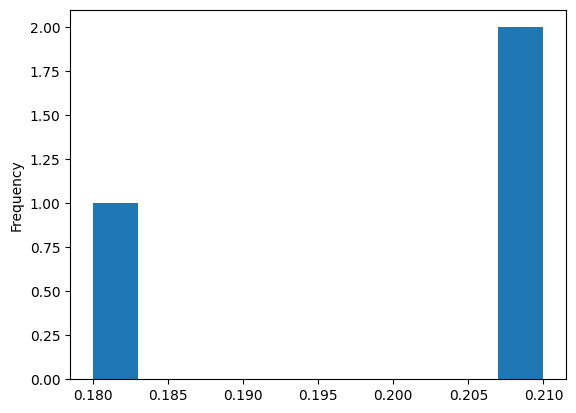

In [ ]:
# Mostrar diagrama de barras de precios
df.IVA.plot(kind='hist')


# Integración con NumPy

Pandas se encuentra perfectamente integrado con NumPy, de modo que podemos traducir un Dataframe a un array NumPy y viceversa. Por ejemplo, la siguiente celda muestra el código para codificar el dataset cargado en memoria como un array NumPy 2D:

In [ ]:
import numpy as np

np_data= df.to_numpy()

print('El conjunto de datos en NumPy:\n{}'.format(np_data))

El conjunto de datos en NumPy:
[['Pechuga de pollo' 0.5 8.0]
 ['Manzanas' 1.0 2.35]
 ['Jamón York' 0.25 10.0]]


# Ejercicio

Cargue el conjunto de datos de la *Flor de Iris* desde el siguiente enlace utilizando Pandas:

<a href="https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv">https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv</a>

Utilice las funciones descritas en este cuaderno para inspeccionar los datos.

In [ ]:
# Solución